# Setup

In [15]:
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

from IPython.display import display
from sklearn.compose import ColumnTransformer, make_column_transformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, GridSearchCV, cross_validate, train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, PolynomialFeatures, StandardScaler

ROOT = Path("/Users/higgins/Documents/UWGrad/Conferences_Apps_Projects/DAIR3/DAIR3-Workshop/resources/unit_4")
DATA_DIR = ROOT / "data"
IMAGE_DIR = ROOT / "images"
RANDOM_STATE = 42

pd.options.plotting.backend = "plotly"
pio.templates["palatino_white"] = go.layout.Template(pio.templates["plotly_white"])
pio.templates["palatino_white"].layout.font.family = "Palatino, Palatino Linotype, Book Antiqua, serif"
pio.templates["palatino_white"].data.scatter = [go.Scatter(marker={"size": 8})]
pio.templates["palatino_white"].data.scattergl = [go.Scattergl(marker={"size": 8})]
pio.templates.default = "palatino_white"
px.defaults.template = "palatino_white"
px.defaults.width = 840
px.defaults.height = 460


def display_df(df, rows=10):
    return display(df.head(rows))


def make_polynomial_sample(n=80, random_state=23):
    rng = np.random.default_rng(random_state)
    x = np.linspace(-5, 5, n)
    y = 2 + 0.8 * x - 0.35 * x ** 2 + 0.08 * x ** 3 + rng.normal(0, 3, n)
    return pd.DataFrame({"x": x, "y": y})


def one_hot_encoder(**kwargs):
    try:
        return OneHotEncoder(sparse_output=False, **kwargs)
    except TypeError:
        return OneHotEncoder(sparse=False, **kwargs)


def find_birthweight_file(year=1971):
    candidates = [
        DATA_DIR / f"{year}.csv.gz",
        ROOT.parent / "DAIR3-Workshop" / "resources" / "unit_3" / "data" / f"{year}.csv.gz",
        ROOT.parent / "resources" / "unit_3" / "data" / f"{year}.csv.gz",
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    searched = "\n".join(f"- {candidate}" for candidate in candidates)
    raise FileNotFoundError(
        "Could not find the prepared NCHS birthweight CSV. "
        "Run the Unit 3 prep.py script first, or place 1971.csv.gz in materials-draft/data.\n"
        f"Searched:\n{searched}"
    )


def load_birthweight_1971():
    return pd.read_csv(find_birthweight_file(1971))


def prepare_birthweight_modeling_data():
    births = load_birthweight_1971()
    cols = ["birthweight", "sex", "momage", "dadage", "plurality", "birthorder"]
    return births[cols].dropna().copy()


def make_interpretable_pipeline(numeric_cols, categorical_cols, model=None, scale_numeric=False):
    if model is None:
        model = LinearRegression()
    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", Pipeline(numeric_steps), numeric_cols),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore")),
            ]), categorical_cols),
        ],
        remainder="drop",
    )
    return Pipeline([("preprocessor", preprocessor), ("model", model)])


def regression_metrics(y_true, predictions):
    return pd.Series({
        "MAE": mean_absolute_error(y_true, predictions),
        "RMSE": mean_squared_error(y_true, predictions) ** 0.5,
        "R2": r2_score(y_true, predictions),
    })


def train_test_evaluate(model, X, y, test_size=0.2, random_state=RANDOM_STATE):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return {"model": model, "X_train": X_train, "X_test": X_test, "y_train": y_train, "y_test": y_test, "predictions": preds, "metrics": regression_metrics(y_test, preds)}


def compute_vif(X_numeric):
    X_clean = X_numeric.dropna().astype(float)
    values = X_clean.to_numpy()
    vifs = []
    for i in range(values.shape[1]):
        y = values[:, i]
        others = np.delete(values, i, axis=1)
        others = np.column_stack([np.ones(len(others)), others])
        fitted = others @ np.linalg.lstsq(others, y, rcond=None)[0]
        ss_res = np.sum((y - fitted) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0
        vifs.append(np.inf if np.isclose(r2, 1) else 1 / (1 - r2))
    return pd.DataFrame({
        "feature": X_clean.columns,
        "VIF": vifs,
    }).sort_values("VIF", ascending=False)


def residual_frame(result):
    return result["X_test"].copy().assign(
        actual=result["y_test"].to_numpy(),
        predicted=result["predictions"],
        residual=result["y_test"].to_numpy() - result["predictions"],
    )


def subgroup_metrics(frame, actual_col="actual", pred_col="predicted", group_col="urbanicity"):
    def summarize(group):
        return pd.Series({
            "n": len(group),
            "MAE": mean_absolute_error(group[actual_col], group[pred_col]),
            "RMSE": mean_squared_error(group[actual_col], group[pred_col]) ** 0.5,
            "mean_residual": (group[actual_col] - group[pred_col]).mean(),
        })
    return frame.groupby(group_col, observed=True).apply(summarize).sort_values("MAE", ascending=False)


def pipeline_coefficients(model, model_step="model", preprocessor_step="preprocessor"):
    fitted = model.best_estimator_ if hasattr(model, "best_estimator_") else model
    if hasattr(fitted, "named_steps"):
        preprocessor = fitted.named_steps.get(preprocessor_step)
        estimator = fitted.named_steps.get(model_step, fitted.steps[-1][1])
        if preprocessor is not None and hasattr(preprocessor, "get_feature_names_out"):
            names = preprocessor.get_feature_names_out()
        else:
            names = np.arange(len(estimator.coef_))
    else:
        estimator = fitted
        names = np.arange(len(estimator.coef_))
    return pd.Series(estimator.coef_, index=names, name="coefficient").sort_values(key=np.abs, ascending=False)


def commute_coefs(model):
    fitted = model.best_estimator_ if hasattr(model, "best_estimator_") else model
    names = fitted[0].get_feature_names_out()
    coefs = fitted[-1].coef_
    return pd.Series(coefs, index=names)


# Load in NCHS data 

In [16]:
try:
    births = load_birthweight_1971()
    print(f"Loaded {births.shape[0]:,} births and {births.shape[1]:,} columns.")
    display(births.sample(5))
except FileNotFoundError as err:
    births = None
    print(err)


Loaded 1,781,774 births and 14 columns.


,year,state,county,smsa,sex,dadrace,momrace,momage,birthorder,dadage,birthweight,plurality,interval,popsize
100525,1971,5,010,073,female,White,White,17,1.0,21.0,2892.0,1,NaN,9
519258,1971,15,002,071,female,White,White,23,2.0,23.0,3686.0,1,39.0,9
89835,1971,5,019,114,male,White,White,20,1.0,26.0,3260.0,1,NaN,9
139502,1971,5,050,129,male,White,White,26,2.0,28.0,3260.0,1,25.0,9
1653909,1971,13,007,000,female,White,White,26,4.0,30.0,3204.0,1,NaN,9


In [ ]:
# how many unique counties are in the data? 307, oh boy
print(births['county'].unique())

<StringArray>
['001', '002', '043', '049', '017', '003', '118', '004', '028', '005',
 ...
 '321', '399', '390', '372', '375', '381', '393', '396', '405', '411']
Length: 307, dtype: str


In [ ]:
## if we want to look at months, need to look at unit 3 script that preps the data and include it .......

          count         mean         std     min     25%     50%      75%  \
county                                                                      
001     43221.0  3238.082483  592.596863   227.0  2920.0  3260.0  3600.00   
002     53262.0  3281.920563  582.154101   227.0  2977.0  3317.0  3629.00   
003     29739.0  3299.160362  568.694598   369.0  2977.0  3317.0  3657.00   
004     27442.0  3242.629983  598.311261   255.0  2920.0  3280.0  3614.75   
005     23164.0  3295.700527  576.546662   227.0  2977.0  3317.0  3657.00   
...         ...          ...         ...     ...     ...     ...      ...   
402      1583.0  3302.180038  578.134711   369.0  3005.0  3345.0  3657.00   
405       159.0  3246.352201  576.047281  1219.0  2948.0  3232.0  3643.00   
408       131.0  3301.160305  524.541218  1673.0  2948.0  3289.0  3629.00   
411       140.0  3247.314286  498.443940  1304.0  2948.0  3317.0  3515.00   
ZZZ      3782.0  3434.400317  593.615485   369.0  3147.0  3402.0  3742.00   

/var/folders/vy/r1hqxzr55gb0nzc3d5fbj8xr0000gq/T/ipykernel_91686/1801966765.py:10: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


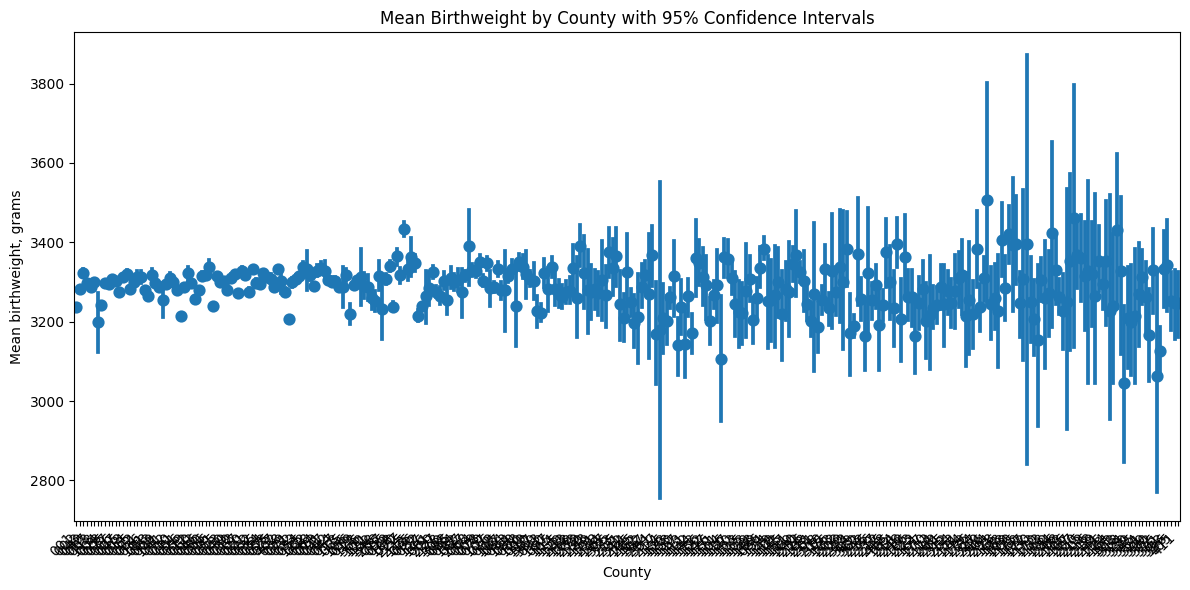

In [21]:
# descriptive statistic or effect size that provides initial insight into your research question
print(births.groupby("county")['birthweight'].describe())


import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

sns.pointplot(
    data=births,
    x="county",
    y="birthweight",
    errorbar=("ci", 95),
    join=False
)

plt.xticks(rotation=45, ha="right")
plt.xlabel("County")
plt.ylabel("Mean birthweight, grams")
plt.title("Mean Birthweight by County with 95% Confidence Intervals")
plt.tight_layout()
plt.show()